# Exploratory Data Analysis

In [1]:
!pip install kaggle -q

In [2]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [3]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip
!ls -lh

100% 285M/285M [00:01<00:00, 201MB/s]

total 952M
-rw-r--r-- 1 root root 286M Dec 11  2019 challenges-in-representation-learning-facial-expression-recognition-challenge.zip
-rw-r--r-- 1 root root 7.1K Dec 11  2019 example_submission.csv
-rw-r--r-- 1 root root  92M Dec 11  2019 fer2013.tar.gz
-rw-r--r-- 1 root root 288M Dec 11  2019 icml_face_data.csv
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data
-rw-r--r-- 1 root root  58M Dec 11  2019 test.csv
-rw-r--r-- 1 root root 230M Dec 11  2019 train.csv


# Data Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('icml_face_data.csv')
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("coolumns:", df.columns.tolist())
print("\nUsage split:")
print(df['Usage'].value_counts())
print("\nEmotion distribution:")
print(df['emotion'].value_counts().sort_index())

Shape: (35887, 3)
coolumns: ['emotion', 'Usage', 'pixels']

Usage split:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

Emotion distribution:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64


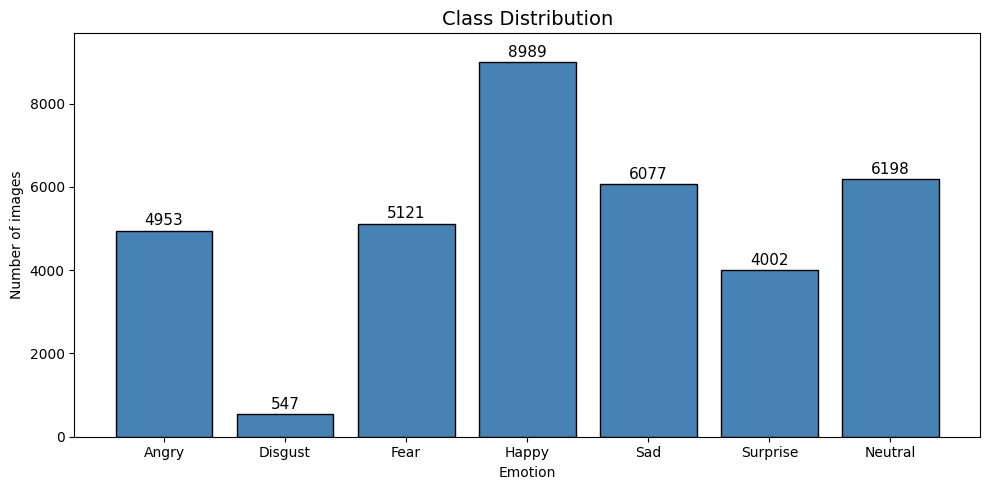

In [5]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
counts = df['emotion'].value_counts().sort_index().values

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(emotion_labels, counts, color='steelblue', edgecolor='black')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=11)

ax.set_title('Class Distribution', fontsize=14)
ax.set_xlabel('Emotion')
ax.set_ylabel('Number of images')
ax.set_ylim(0, max(counts) + 700)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

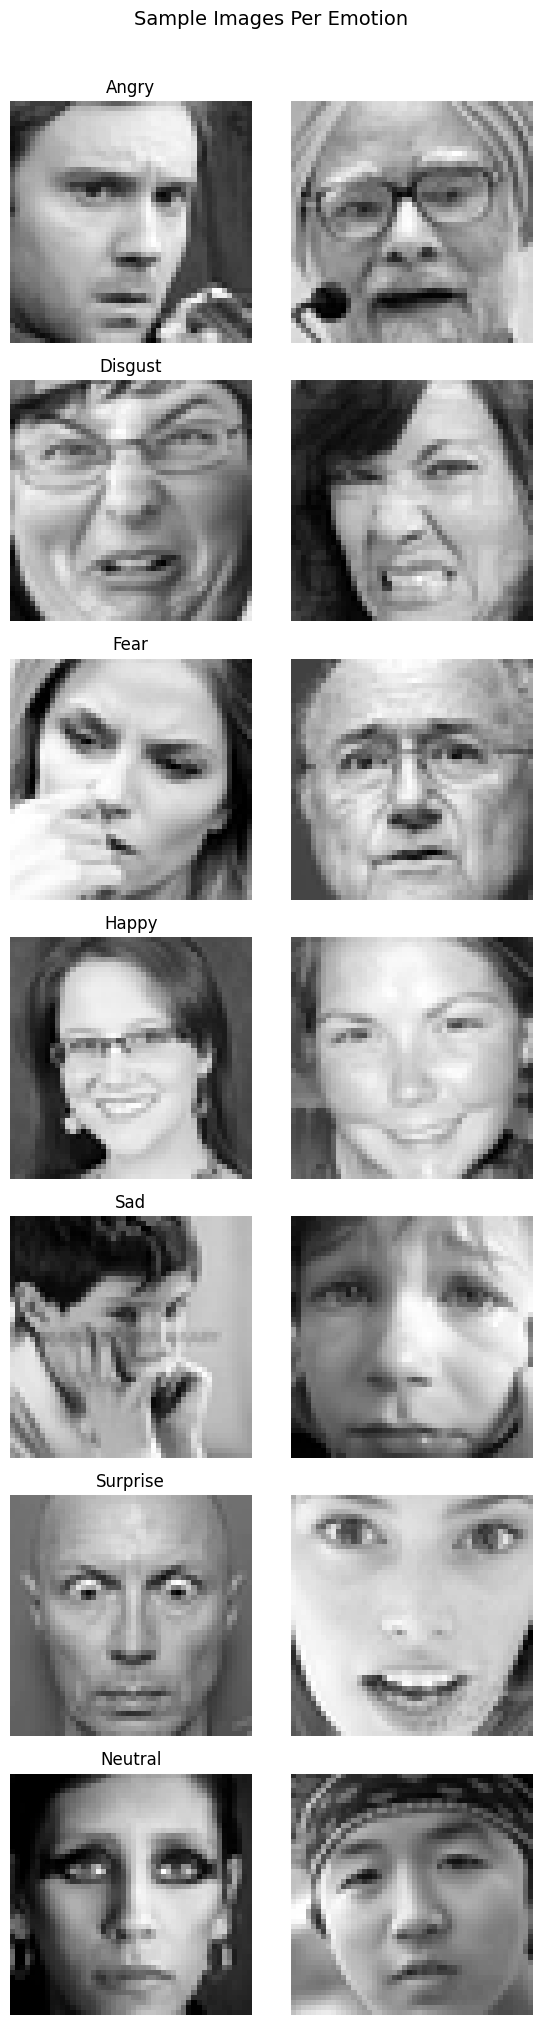

In [6]:
fig, axes = plt.subplots(7, 2, figsize=(6, 20))

for emotion_idx in range(7):
    samples = df[df['emotion'] == emotion_idx].head(2)
    for col, (_, row) in enumerate(samples.iterrows()):
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        axes[emotion_idx][col].imshow(pixels, cmap='gray')
        axes[emotion_idx][col].axis('off')
        if col == 0:
            axes[emotion_idx][col].set_title(emotion_labels[emotion_idx], fontsize=12)

plt.suptitle('Sample Images Per Emotion', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

In [7]:
train_df = df[df['Usage'] == 'Training']
val_df = df[df['Usage'] == 'PublicTest']
test_df = df[df['Usage'] == 'PrivateTest']

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"test:  {len(test_df)} images")
print(f"Total: {len(df)} images")

Train: 28709 images
Val:   3589 images
test:  3589 images
Total: 35887 images
